# Step 4.1

The number of chargers in the network is defined in step 3 initially, but in order to optimize it, it will be re-calculated (the minimun needed chargers decided) in Step 4.1., and this will be used in dumb charging and step 4 and 5

New constrains added:
- The state of the charge in the final time step needs to be 50 % of the capacity, since otherwise it would go to zero, which is not desirable
- The number of chargers can not exceed the number of cars, since the available capacity for charging for each time step is calculated as Number_of_chargers * capacity_of_charger, and then the availability would be wrong


Idea for Step 5

- look at all the shops and the base load for each time step
- calculate the load for each time step
- minimize the standard deviation of the summed loads over time steps


Processing schedule_Airmee ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 2 chargers: No value for uninitialized VarData object P[0,1]
  Testing 3 chargers ...
   ✅ Feasible with 3 chargers, cost = 81727.37 €
  -> Minimum chargers 

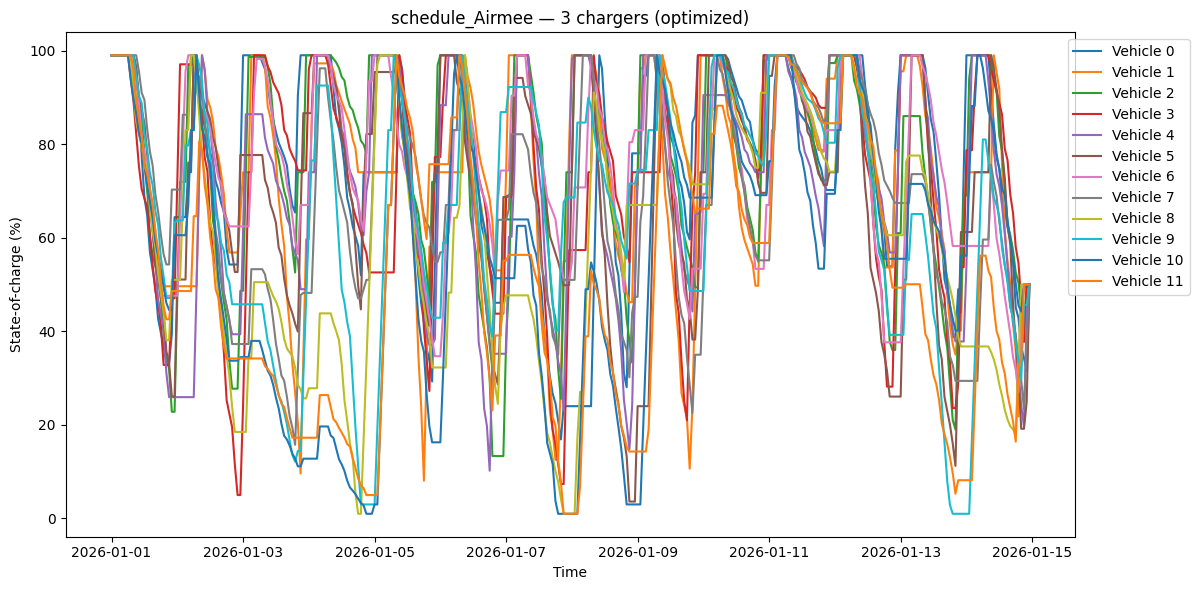

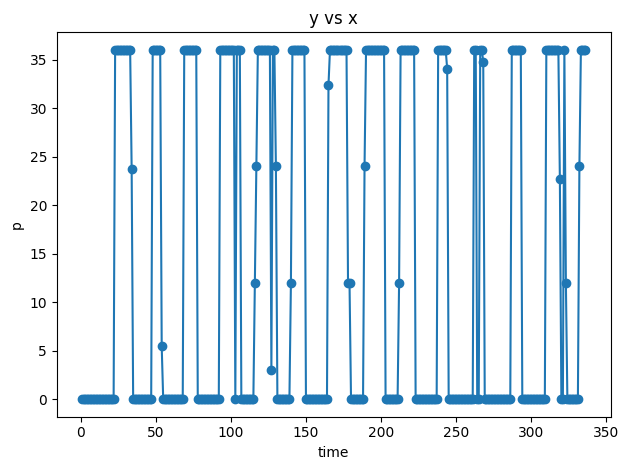


Processing schedule_Postnord ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 2 chargers: No value for uninitialized VarData object P[0,1]
  Testing 3 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <c

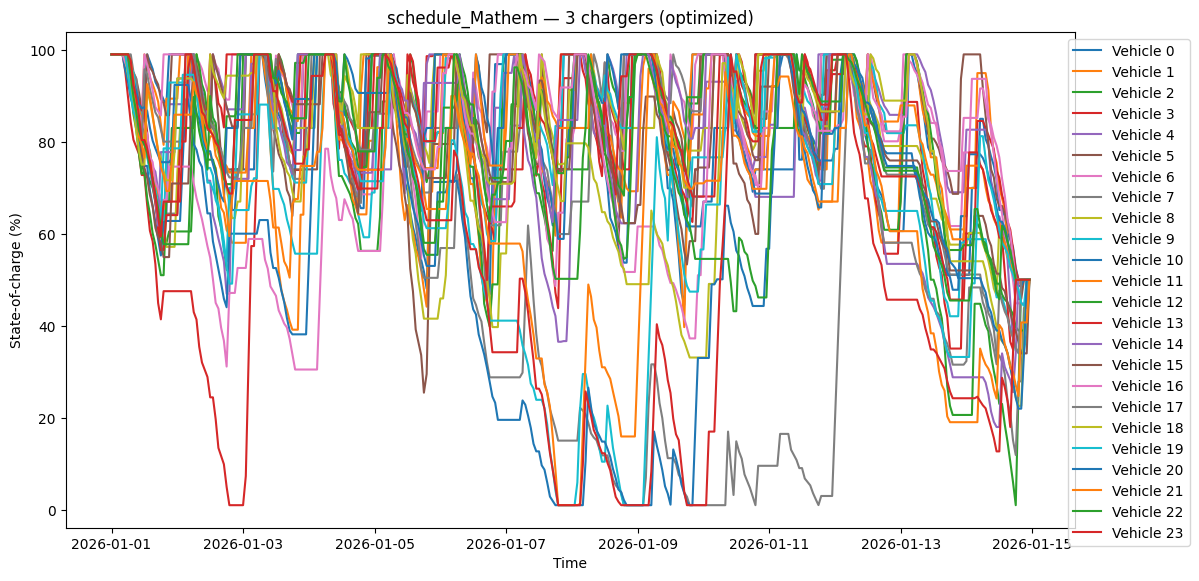

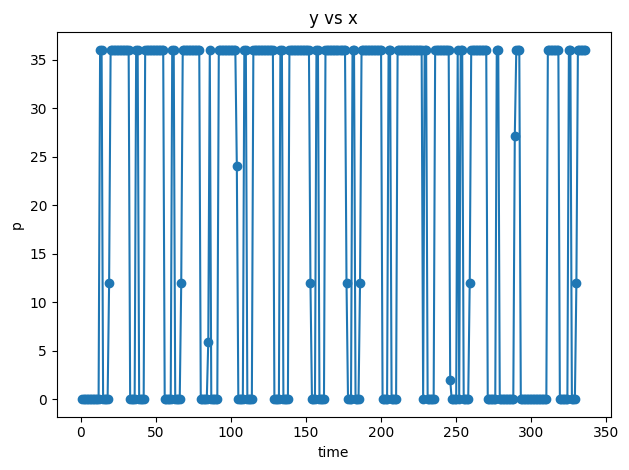


Processing schedule_ICA ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
   ✅ Feasible with 2 chargers, cost = 60927.62 €
  -> Minimum chargers required: 2


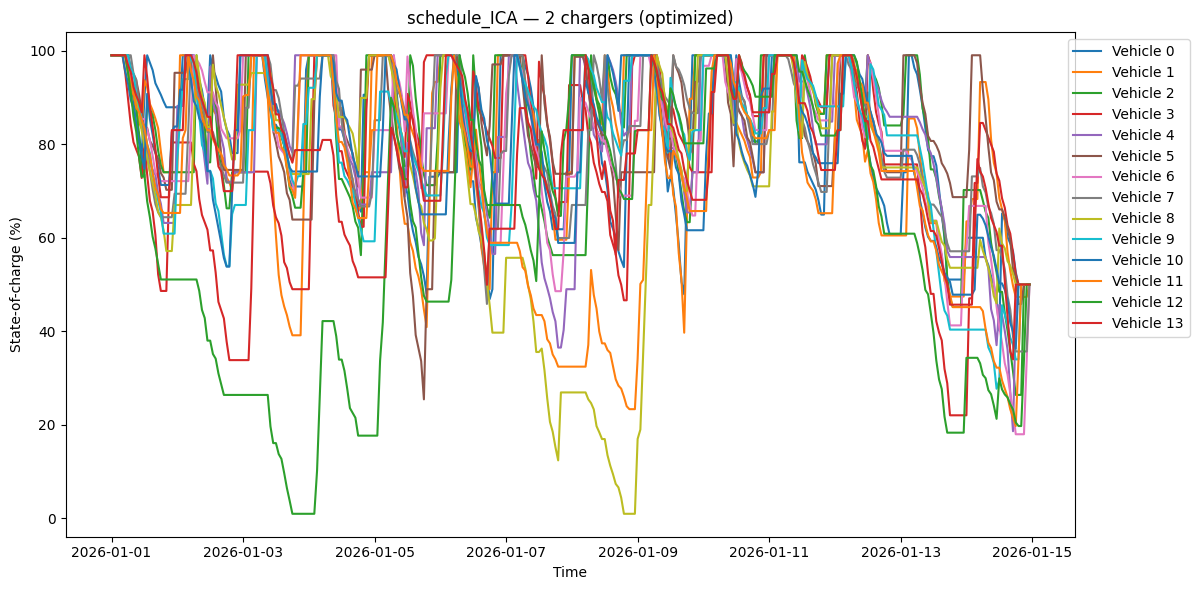

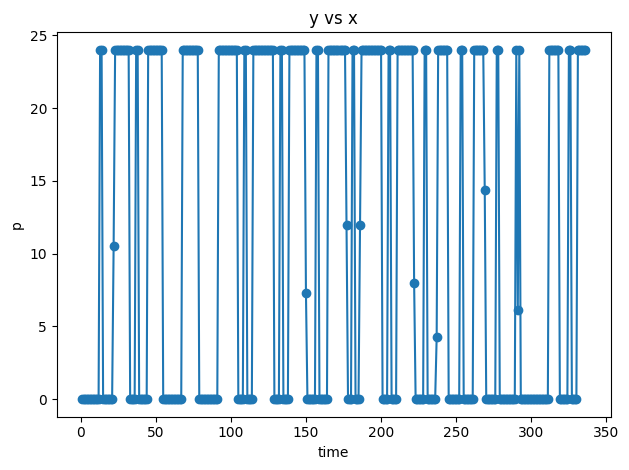


Summary:
 schedule_Airmee: 3 chargers (reason=ok)
 schedule_Postnord: None chargers (reason=not_feasible)
 schedule_Mathem: 3 chargers (reason=ok)
 schedule_ICA: 2 chargers (reason=ok)


In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import timedelta
import math
import csv

# Pyomo imports
from pyomo.environ import (
    ConcreteModel, Var, Set, Param, Objective, Constraint, NonNegativeReals,
    Reals, SolverFactory, value, summation
)

import matplotlib.pyplot as plt

# -------------------------
# Config / mappings (same as you had)
# -------------------------
vehicle_charging_limits = {"Renault": 80.0, "Toyota": 100.0}   # kW inlet per vehicle type
battery_capacities = {"Renault": 48.0, "Toyota": 75.0}        # kWh per vehicle type
SOC_max_percentage = 0.99  # max state-of-charge fraction (to avoid overcharging)
SOC_min_percentage = 0.01  # min state-of-charge fraction (to avoid deep discharge)
SOC_last_time_step_percentage = 0.5 # the percentage of SOC at the last time step

# Charger capacity per physical charger (kW)
FAST_AC_CAPACITY_KW = 12.0

# -------------------------
# Core optimizer: optimize energy cost for one shop CSV and fixed number of chargers
# -------------------------
def optimize_shop_energy_cost(file_path,
                              n_chargers,
                              price_series,
                              solver_name='glpk',
                              verbose=False):
    """
    Build and solve a Pyomo LP that minimizes energy cost for charging
    with a fixed number of chargers.

    Parameters
    ----------
    file_path : str or Path
        Path to shop schedule CSV file (same layout you used: columns include
        'date', 'VehicleID', 'VehicleType', 'Location', 'Consumption_kWh').
    n_chargers : int
        Fixed number of chargers available at the depot.
    price_series : pandas.Series or None
        Optional electricity price indexed by timestamps. If None, a flat price 0.20 €/kWh is used.
    solver_name : str
        Pyomo solver name to attempt. Default 'glpk'. Will try 'cbc' if 'glpk' fails.
    verbose : bool
        If True print solver output.

    Returns
    -------
    dict
        result = {
            'status': solver status string,
            'objective': objective value (€/period),
            'P': dict {(vid, ts): value} charging powers (kW),
            'SOC': dict {vid: [SOC time series in kWh]},
            'time_index': time index (list of timestamps),
            'n_chargers': n_chargers
        }
    """

    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(file_path)

    df = pd.read_csv(file_path)
    if 'date' not in df.columns:
        raise ValueError("CSV must have a 'date' column with timestamps.")
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # Unique sorted time points
    time_index = sorted(df['date'].unique())
    T = len(time_index)
    if T < 1:
        raise ValueError("No timestamps found in file.")

    # Map timestamps to integer indices for Pyomo (1..T)
    time_to_idx = {ts: idx+1 for idx, ts in enumerate(time_index)}
    idx_to_time = {idx+1: ts for idx, ts in enumerate(time_index)}

    # Compute delta_t per time step (hours). For last step we reuse previous delta.
    delta_hours = {}
    for idx in range(1, T+1):
        if idx == 1:
            # for first time-step, if there is a second timestamp use difference,
            # otherwise default to 1 hour
            if T >= 2:
                dt = (idx_to_time[2] - idx_to_time[1]).total_seconds() / 3600.0
            else:
                dt = 1.0
        else:
            dt = (idx_to_time[idx] - idx_to_time[idx-1]).total_seconds() / 3600.0
        # safety: nonzero positive
        if dt <= 0:
            dt = 1.0
        delta_hours[idx] = dt

    # Vehicles
    vehicles = sorted(df['VehicleID'].unique())
    if len(vehicles) == 0:
        raise ValueError("No vehicles found in the schedule CSV.")

    # Vehicle type mapping, inlet and capacity parameters
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    Pmax_by_vehicle = {vid: vehicle_charging_limits.get(vehicle_types.get(vid), FAST_AC_CAPACITY_KW)
                       for vid in vehicles}
    Cap_by_vehicle = {vid: battery_capacities.get(vehicle_types.get(vid), 48.0)
                      for vid in vehicles}

    # Build E_drive[i,t] (consumption) and I[i,t] (availability: 1 if at depot)
    # We'll aggregate rows per timestamp & vehicle (if duplicates present sum consumption and take Location=1 if any)
    idx_cols = ['VehicleID', 'date']
    agg = df.groupby(idx_cols).agg({
        'Consumption_kWh': 'sum',
        'Location': 'max'   # assume Location==1 means at depot
    }).reset_index()

    # initialize dictionaries
    E_drive = {(vid, t): 0.0 for vid in vehicles for t in range(1, T+1)}
    I_at_depot = {(vid, t): 0 for vid in vehicles for t in range(1, T+1)}

    for _, row in agg.iterrows():
        vid = row['VehicleID']
        ts = row['date']
        idx = time_to_idx[ts]
        E_drive[(vid, idx)] = float(row.get('Consumption_kWh', 0.0))
        I_at_depot[(vid, idx)] = 1 if int(row.get('Location', 0)) == 1 else 0

    # Electricity price per time index
    if price_series is None:
        # default flat price
        flat_price = 0.20  # €/kWh
        price_by_idx = {t: flat_price for t in range(1, T+1)}
    else:
        # expect price_series indexed by timestamps
        if not isinstance(price_series, pd.Series):
            # try reading CSV or dict-like
            raise ValueError("price_series must be a pandas.Series indexed by the same timestamps as 'date'.")
        # reindex/align - if missing timestamps in provided series, fill with last valid or flat default
        ps = price_series.copy()
        ps.index = pd.to_datetime(ps.index, format = '%d.%m.%Y %H:%M')
        price_by_idx = {}
        for idx in range(1, T+1):
            try:
                ts = idx_to_time[idx]
                price_by_idx[idx] = ps.iloc[idx-1]
            except:
                raise ValueError("error in creating price indexes")

    # -------------------------
    # Build Pyomo model
    # -------------------------
    model = ConcreteModel()

    # Sets
    model.VEH = Set(initialize=vehicles, ordered=True)
    model.TIME = Set(initialize=list(range(1, T+1)), ordered=True)

    # Parameters
    model.Cap = Param(model.VEH, initialize=Cap_by_vehicle, within=Reals)
    model.PmaxVeh = Param(model.VEH, initialize=Pmax_by_vehicle, within=Reals)
    model.Edrive = Param(model.VEH, model.TIME, initialize=E_drive, within=Reals)
    model.Avail = Param(model.VEH, model.TIME, initialize=I_at_depot, within=Reals)
    model.dt = Param(model.TIME, initialize=delta_hours, within=Reals)
    model.price = Param(model.TIME, initialize=price_by_idx, within=Reals)
    model.n_chargers = Param(initialize=int(n_chargers))
    model.P_charger = Param(initialize=float(FAST_AC_CAPACITY_KW))
    model.SOC_max_percentage = Param(initialize=SOC_max_percentage) 
    model.SOC_min_percentage = Param(initialize=SOC_min_percentage)
    model.Time_steps_amount = Param(initialize=T)
    model.SOC_last_time_step_percentage = Param(initialize=SOC_last_time_step_percentage)

    # Variables: P[veh,time] (kW) and SOC[veh,time] (kWh)
    model.P = Var(model.VEH, model.TIME, domain=NonNegativeReals)
    model.SOC = Var(model.VEH, model.TIME, domain=NonNegativeReals)

    # Objective: minimize sum_t sum_i price_t * P_i_t * dt
    def obj_rule(m):
        return sum(m.price[t] * m.P[v, t] * m.dt[t] for v in m.VEH for t in m.TIME)
    model.obj = Objective(rule=obj_rule, sense=1)  # minimize

    # Constraints

    # 1) Charging availability and per-vehicle max inlet: P_i_t <= Avail_i_t * PmaxVeh_i
    def p_max_rule(m, v, t):
        return m.P[v, t] <= m.Avail[v, t] * m.PmaxVeh[v]
    model.p_max_con = Constraint(model.VEH, model.TIME, rule=p_max_rule)

    # 2) Charger capacity (shared): sum_i P_i_t <= n_chargers * P_charger
    def charger_cap_rule(m, t):
        return sum(m.P[v, t] for v in m.VEH) <= m.n_chargers * m.P_charger
    model.charger_cap_con = Constraint(model.TIME, rule=charger_cap_rule)


    # 2) Charger capacity (shared): sum_i P_i_t <= n_chargers * P_charger
    def charger_cap_rule_unique(m, v, t):
        return m.P[v, t]  <=  m.P_charger
    model.charger_cap_con_uniq = Constraint(model.VEH, model.TIME, rule=charger_cap_rule_unique)


    # 3) SOC dynamics:
    # For t == first index: SOC[v,1] = Cap_v - Edrive[v,1] + P[v,1]*dt[1]
    def soc_first_rule(m, v):
        t = 1
        return m.SOC[v, t] == m.Cap[v] * m.SOC_max_percentage - m.Edrive[v, t] + m.P[v, t] * m.dt[t]
    model.soc_first_con = Constraint(model.VEH, rule=soc_first_rule)

    # For t > 1: SOC[v,t] = SOC[v,t-1] - Edrive[v,t] + P[v,t]*dt[t]
    def soc_evol_rule(m, v, t):
        if t == 1:
            return Constraint.Skip
        return m.SOC[v, t] == m.SOC[v, t-1] - m.Edrive[v, t] + m.P[v, t] * m.dt[t]
    model.soc_evol_con = Constraint(model.VEH, model.TIME, rule=soc_evol_rule)

    # 4) Battery limits: 0 <= SOC <= Cap
    def soc_ub_rule(m, v, t):
        return m.SOC[v, t] <= m.Cap[v] * m.SOC_max_percentage
    model.soc_ub_con = Constraint(model.VEH, model.TIME, rule=soc_ub_rule)
    
    def soc_lb_rule(m, v, t):
        return m.SOC[v, t] >= m.Cap[v]*m.SOC_min_percentage
    model.soc_lb_con = Constraint(model.VEH, model.TIME, rule=soc_lb_rule)

    # at midnight of the last day, the soc should be 50 %  
    def soc_end_rule(m, v):
        t = m.Time_steps_amount
        return m.SOC[v, t] == m.Cap[v] * m.SOC_last_time_step_percentage
    model.soc_end_con = Constraint(model.VEH, rule=soc_end_rule)




    # Lower bound of SOC already enforced by domain NonNegativeReals

    # -------------------------
    # Solve
    # -------------------------
    # Attempt to create a solver and solve
    solver = None
    solver_try_order = [solver_name, 'cbc', 'glpk'] if solver_name != 'glpk' else ['glpk', 'cbc']
    solver_available = False
    last_solver_err = None
    for sname in solver_try_order:
        try:
            solver = SolverFactory(sname)
            if solver is None:
                continue
            # Some backends require 'executable' to be present; we'll just attempt solve and catch exceptions
            res = solver.solve(model, tee=verbose)
            solver_available = True
            break
        except Exception as e:
            last_solver_err = e
            solver = None
            continue

    if not solver_available:
        raise RuntimeError(f"No solver available/working. Tried {solver_try_order}. "
                           f"Last error: {last_solver_err}")

    # Read out solution
    # objective value
    obj_val = value(model.obj)

    P_sol = {}
    P_per_time = {}
    SOC_traces = {v: [] for v in vehicles}
    SOC_traces_percentage = {v: [] for v in vehicles}
    for t in model.TIME:
        all_P = 0.0
        for v in model.VEH:
            P_sol[(v, idx_to_time[t])] = float(value(model.P[v, t]))
            all_P += float(value(model.P[v, t]))
        P_per_time[t] = all_P

        
    for v in vehicles:
        for t in model.TIME:
            SOC_traces[v].append(float(value(model.SOC[v, t])))
            SOC_traces_percentage[v].append(float(value(model.SOC[v, t]/model.Cap[v])))

    n_vehicles = len(vehicles)
    if n_chargers > n_vehicles:
        raise RuntimeError(f"No feasible solution found, number of chargers", n_chargers, "would be higher than number of vehicles", n_vehicles)


    result = {
        'status': str(res.solver.termination_condition) if hasattr(res, 'solver') else 'unknown',
        'objective': obj_val,
        'P': P_sol,
        'P_time' : P_per_time,
        'SOC': SOC_traces,
        'time_index': [idx_to_time[t] for t in model.TIME],
        'n_chargers': int(n_chargers),
        'solver': solver,
        'SOC_percentage' : SOC_traces_percentage
    }

    return result

# -------------------------
# Optional: plotting helper
# -------------------------
def plot_soc_from_result(result, title=None, save_fig=False, out_path=None):
    time = result['time_index']
    soc_percentage = result['SOC_percentage']
    p_shop = result['P_time']

    plt.figure(figsize=(12, 6))
    for vid, series in soc_percentage.items():
        series_pct = [s * 100.0 for s in series]  # convert to percentage
        plt.plot(time, series_pct, label=f"Vehicle {vid}")
        
    plt.xlabel("Time")
    plt.ylabel("State-of-charge (%)")
    if title is None:
        title = f"SOC over time — {result.get('n_chargers', '?')} chargers"
    plt.title(title)
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
    plt.tight_layout()
    if save_fig:
        if out_path is None:
            out_path = Path("soc_plot.png")
        plt.savefig(out_path, dpi=150)
        print("Saved figure to", out_path)
    plt.show()


    xs, ys = zip(*sorted(p_shop.items()))  # sort by key for a proper line
    plt.plot(xs, ys, marker="o")
    plt.xlabel("time")
    plt.ylabel("p")
    plt.title("y vs x")
    plt.tight_layout()
    plt.show()
        

def open_price_file():
    
    prices = {}
    date_format = '%d.%m.%Y %H:%M'

    with open("Prices.csv", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)              
        header = next(reader, None)        
        for row in reader:
            from_time = row[0].split(" - ")[0]
            prices[from_time] = float(row[1])
    prices_pd = pd.Series(prices)
    return prices_pd

# -------------------------
# Example / if called as script
# -------------------------
if __name__ == "__main__":
    base_path = Path(os.getcwd()).parent / "data" / "Output"
    shops = ["schedule_Airmee", "schedule_Postnord", "schedule_Mathem", "schedule_ICA"]

    results = {}
    MAX_CHARGERS_TO_TEST = 29

    for shop in shops:
        shop_folder = base_path / shop
        file = shop_folder / f"{shop}.csv"
        if not file.exists():
            print(f"[WARN] file not found: {file}")
            results[shop] = {'min_chargers': None, 'reason': 'file_missing'}
            continue

        print(f"\nProcessing {shop} ...")

        # Test decreasing number of chargers: 20 down to 1
        found = False
        best_trace = None
        best_cost = None
        prices = open_price_file()
        for n_ch in range(1, MAX_CHARGERS_TO_TEST, 1):
            print(f"  Testing {n_ch} chargers ...")
            try:
                res = optimize_shop_energy_cost(file, n_chargers=n_ch, price_series=prices, solver_name='glpk', verbose=False)
            except Exception as e:
                print(f"   Solver failed for {n_ch} chargers: {e}")
                continue

            # Evaluate feasibility: if SOC never goes below 0
            feasible = all(all(val >= -1e-6 for val in soc_list) for soc_list in res['SOC'].values())

            if feasible:
                print(f"   ✅ Feasible with {n_ch} chargers, cost = {res['objective']:.2f} €")
                found = True
                best_trace = res
                best_cost = res['objective']
                best_trace_percentage = res['SOC_percentage']
                # continue searching for smaller feasible? Since we go 20→1, break on first feasible
                break
            else:
                print(f"   ❌ Infeasible with {n_ch} chargers (battery empty at some point)")

        if found:
            print(f"  -> Minimum chargers required: {n_ch}")
            results[shop] = {
                'min_chargers': n_ch,
                'objective': best_cost,
                'trace': best_trace,
                'trace_percentage': best_trace['SOC_percentage']
            }
            # Optionally plot SOC
            df = pd.read_csv(file)
            vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()

            plot_soc_from_result(best_trace, title=f"{shop} — {n_ch} chargers (optimized)", save_fig=False)
        else:
            print(f"  -> Not feasible with up to {MAX_CHARGERS_TO_TEST} chargers.")
            results[shop] = {'min_chargers': None, 'reason': 'not_feasible'}

    print("\nSummary:")
    for shop, info in results.items():
        print(f" {shop}: {info.get('min_chargers')} chargers (reason={info.get('reason','ok')})")
